In [104]:
import numpy as np
import os
import random
import cv2
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix , ConfusionMatrixDisplay , accuracy_score , classification_report
from tensorflow.keras import layers , models
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [105]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout , BatchNormalization , GlobalAveragePooling2D

In [106]:
from google.colab import drive



In [107]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [108]:
real_train_dir = "/content/drive/My Drive/Deep_fake/ffhq_7k/train"
fake_train_dir = "/content/drive/My Drive/Deep_fake/StyleGAN2_7k/train"

In [109]:
real_test_dir = "/content/drive/My Drive/Deep_fake/ffhq_7k/test"
fake_test_dir = "/content/drive/My Drive/Deep_fake/ffhq_7k/test"


In [110]:
def preprocess_image(image_path  , IMG_SIZE = (128 , 128)):
  img = cv2.imread(image_path)
  img = cv2.cvtColor(img , cv2.COLOR_BGR2RGB)
  img = cv2.resize(img , IMG_SIZE)

  img = img.astype(np.float32) / 255.0
  return img


In [111]:
import os

def load_images_from_split(base_dir , split="train", label=0 , img_size=(224, 224)):
    images = []
    labels = []

    split_dir = os.path.join(base_dir, split)

    for file in os.listdir(split_dir):
      img_path = os.path.join(split_dir, file)
      img = preprocess_image(img_path, img_size)
      images.append(img)
      labels.append(label)

    return np.array(images), np.array(labels)


In [57]:
# checking image loading and preprocessing
test_img_path = f"{real_image_dir}/00000.png"

preprocessed = preprocess_image(test_img_path , (64 , 64))
original = cv2.imread(test_img_path)
original = cv2.cvtColor(original , cv2.COLOR_BGR2RGB)


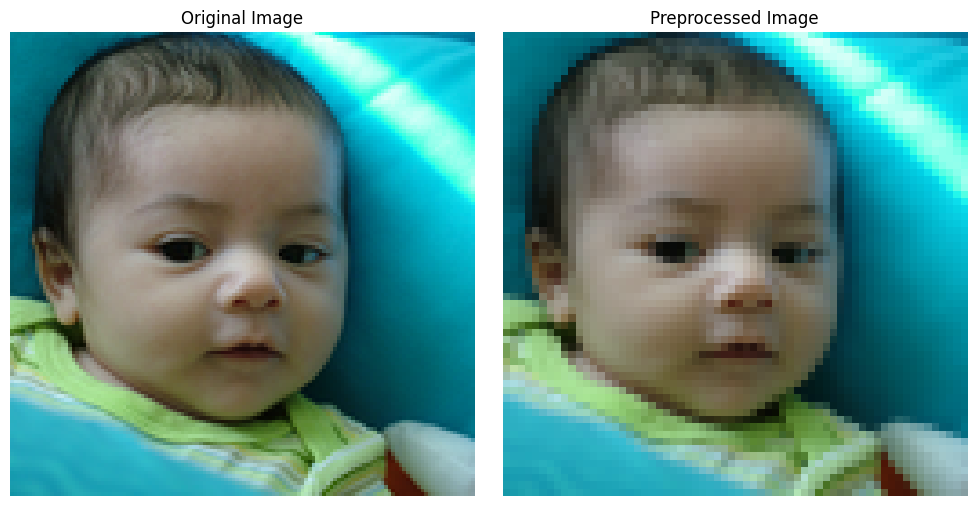

In [58]:
import matplotlib.pyplot as plt



plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(original)
plt.title("Original Image")
plt.axis("off")

plt.subplot(1, 2, 2)
plt.imshow(preprocessed)
plt.title("Preprocessed Image")
plt.axis("off")

plt.tight_layout()
plt.show()

In [112]:

def load_real_fake_images(real_dir, fake_dir, img_size=(128, 128)):
    X = []
    y = []

    # ---- REAL IMAGES (label = 0) ----
    for file in os.listdir(real_dir)[:200]:
        img_path = os.path.join(real_dir, file)
        img = preprocess_image(img_path, img_size)
        X.append(img)
        y.append(0)

    # ---- FAKE IMAGES (label = 1) ----
    for file in os.listdir(fake_dir)[:200]:
        img_path = os.path.join(fake_dir, file)
        img = preprocess_image(img_path, img_size)
        X.append(img)
        y.append(1)

    return np.array(X), np.array(y)


In [113]:
X_train, y_train = load_real_fake_images(
    real_train_dir,
    fake_train_dir
)


In [114]:
print(X_train.shape)
print(y_train.shape)

(400, 128, 128, 3)
(400,)


In [115]:
def build_spatial_cnn(input_shape=(128, 128, 3)):
    model = Sequential()


    # -------- Block 1 --------
    model.add(Conv2D(32, (3,3), padding='same', activation='relu',
                     input_shape=input_shape))

    model.add(MaxPooling2D(2,2))

    # -------- Block 2 --------
    model.add(Conv2D(64, (3,3), padding='same', activation='relu'))

    model.add(MaxPooling2D(2,2))

    # -------- Block 3 --------
    model.add(Conv2D(128, (3,3), padding='same', activation='relu'))

    model.add(MaxPooling2D(2,2))

    # -------- Classifier --------
    model.add(Flatten())
    model.add(Dense(128, activation='relu'))
    # model.add(Dropout(0.4))
    model.add(Dense(1, activation='sigmoid'))

    return model

In [116]:
model = build_spatial_cnn()
model.summary()


Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_21 (Conv2D)              │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_21 (MaxPooling2D) │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_22 (Conv2D)              │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_22 (MaxPooling2D) │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_23 (Conv2D)              │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_23 (MaxPooling2D) │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_14 (Dense)                │ (None, 128)            │     4,194,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_15 (Dense)                │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,287,809 (16.36 MB)

 Trainable params: 4,287,809 (16.36 MB)

 Non-trainable params: 0 (0.00 B)

In [117]:
def compile_model(model):
    model.compile(optimizer='adam' , loss='binary_crossentropy', metrics=['accuracy'])
    return model


In [118]:
def train_model(model, X_train, y_train, X_test, y_test,
                epochs=15, batch_size=10):

    history = model.fit(
        X_train, y_train,
        validation_data=(X_test, y_test),
        epochs=epochs,
        batch_size=batch_size,
        shuffle=True,
        verbose=1   # live progress bar
    )

    return history


In [119]:
X_train , y_train = load_real_fake_images(
    real_train_dir,
    fake_train_dir
)

X_test, y_test = load_real_fake_images(
    real_test_dir,
    fake_test_dir
)


In [120]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(400, 128, 128, 3)
(400,)
(400, 128, 128, 3)
(400,)


In [121]:
model = build_spatial_cnn()
model = compile_model(model)

history = train_model(
    model,
    X_train, y_train,
    X_test, y_test,
    epochs=10
)


Epoch 1/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 4s 31ms/step - accuracy: 0.4826 - loss: 0.8620 - val_accuracy: 0.5000 - val_loss: 0.6934
Epoch 2/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6009 - loss: 0.6803 - val_accuracy: 0.5000 - val_loss: 0.7374
Epoch 3/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6471 - loss: 0.6104 - val_accuracy: 0.5000 - val_loss: 1.2287
Epoch 4/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6998 - loss: 0.6482 - val_accuracy: 0.5000 - val_loss: 1.3082
Epoch 5/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6416 - loss: 0.6434 - val_accuracy: 0.5000 - val_loss: 1.0177
Epoch 6/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.7599 - loss: 0.5126 - val_accuracy: 0.5000 - val_loss: 1.4866
Epoch 7/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8456 - loss: 0.3647 - val_accuracy: 0.5000 - val_loss: 1.3483
Epoch 8/10
40/40 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.8511 - loss: 0.3493 - val_accuracy: 0.5000 - v

In [122]:
# Predict on test data
y_pred = model.predict(X_test)
y_pred = (y_pred > 0.5).astype(int)

# Accuracy
acc = accuracy_score(y_test, y_pred)
print("Test Accuracy:", acc)

# Detailed report
report = classification_report(
    y_test,
    y_pred,
    target_names=["Real", "Fake"]
)

print("\nClassification Report:\n")
print(report)

13/13 ━━━━━━━━━━━━━━━━━━━━ 3s 113ms/step
Test Accuracy: 0.5

Classification Report:

              precision    recall  f1-score   support

        Real       0.50      0.71      0.59       200
        Fake       0.50      0.29      0.37       200

    accuracy                           0.50       400
   macro avg       0.50      0.50      0.48       400
weighted avg       0.50      0.50      0.48       400

